# Bài tập Decision Tree

## Sử dụng Decision Tree để phân nhóm cho tập Iris dataset
- dataset: 'Iris.csv'


In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score
import graphviz

In [26]:
# Load dữ liệu
df = pd.read_csv('Iris.csv')

# Xem 5 dòng đầu tiên
print(df.head())

# Kiểm tra giá trị Null
print(df.info())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [27]:
# Loại bỏ cột Id nếu có
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Tách features (X) và labels (y)
X = df.drop('Species', axis=1)
y = df['Species']

# Chia tập dữ liệu thành Training set và Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Khởi tạo mô hình Decision Tree
clf = DecisionTreeClassifier(criterion='gini', max_depth=4)

# Huấn luyện mô hình
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [29]:
# Dự đoán trên tập Test
y_pred = clf.predict(X_test)

# Tính độ chính xác
accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác của mô hình Iris: {accuracy * 100:.2f}%")

Độ chính xác của mô hình Iris: 100.00%


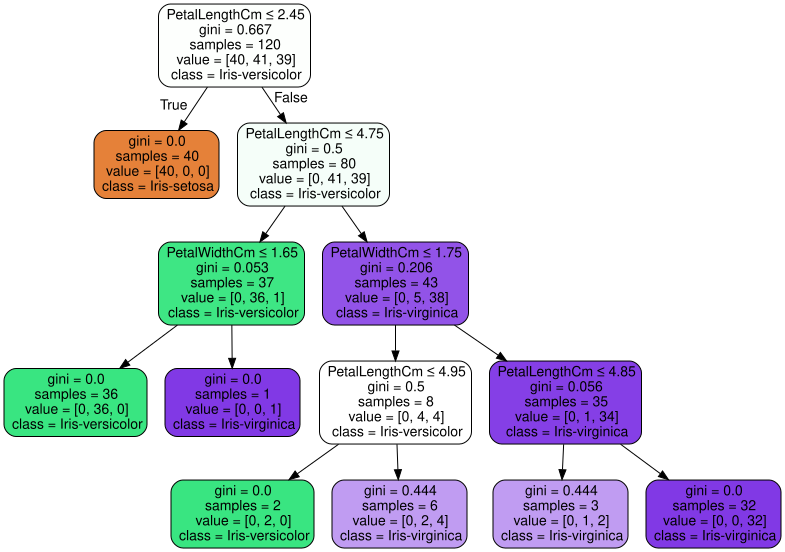

In [30]:
# Xuất dữ liệu cây
dot_data = export_graphviz(clf, out_file=None,
                           feature_names=X.columns,
                           class_names=df['Species'].unique(),
                           filled=True, rounded=True,
                           special_characters=True)

# Hiển thị biểu đồ
graph = graphviz.Source(dot_data)
graph